# Step 4 Analysis — Scoring the Models

The demo notebooks ([`04a_closed_book.ipynb`](../demos/04a_closed_book.ipynb),
[`04b_web_search.ipynb`](../demos/04b_web_search.ipynb),
[`04c_debate.ipynb`](../demos/04c_debate.ipynb))
ran each answering method once, live. This notebook reads the full sweep's
outputs and builds the leaderboard.

**Prerequisites** — run the sweep from the repo root first:

```bash
# 04-1: closed book + web search, all six models (1,200 calls)
for METHOD in closed_book web_search; do
  for M in gpt-5.4-mini-2026-03-17 gpt-5.5-2026-04-23 gpt-5.6-luna \
           gpt-5.6-terra gemini-3.1-flash-lite gemini-3.5-flash; do
    uv run python scripts/04-1_generate_answers.py \
        --model $M --method $METHOD --parallel
  done
done

# 04-2: debate, one model (900 calls — 9 per question)
uv run python scripts/04-2_generate_debate_answers.py \
    --model gpt-5.4-mini-2026-03-17 --parallel

# 04-3: merge every per-run file into one tidy CSV
uv run python scripts/04-3_combine_answers.py \
    --input-dir data/answers --glob 'answers_*.jsonl'
```

Those commands produce the per-run JSONL files and the tidy
`data/answers/answers_combined.csv`.

## 1. Loading the combined answers

From here on we assume the sweep already ran. The tidy CSV has one row per
(question × model × method), graded and ready — the debate transcripts stay
behind in the JSONL files:


In [ ]:
import pandas as pd

df = pd.read_csv("../../data/answers/answers_combined.csv")
print(
    f"{len(df)} answers = {df['question_id'].nunique()} questions x "
    f"{df['model'].nunique()} models x {df['method'].nunique()} methods"
)
df.head(3)[
    ["question_id", "method", "model", "answer_letter", "is_correct", "confidence"]
]

20 answers = 5 questions x 2 models x 3 methods


,question_id,method,model,answer_letter,is_correct,confidence
0,gemini__environment/2026/jul/16/how-green-andy...,closed_book,gpt-5.4-mini-2026-03-17,B,False,0.860000
1,gemini__environment/2026/jul/16/how-green-andy...,debate,gpt-5.4-mini-2026-03-17,C,True,0.976667
2,gemini__environment/2026/jul/16/how-green-andy...,web_search,gemini-3.1-flash-lite,C,True,1.000000


## 2. The leaderboard: accuracy by method

The headline figure — every model under every condition, one panel:
grouped bars per model, one color per method, all on the same 0–100
scale. Debate is the expensive condition (9 calls per question), so the
sweep runs it for one model only — that model simply carries a third bar;
the others have none:


In [ ]:
import matplotlib.pyplot as plt

from toolkit.plotting import BLUE, INK, MUTED, NEUTRAL, clean_axes

ORANGE = "#d97e32"  # debate's hue; CVD-checked against BLUE
METHOD_COLORS = {"closed_book": NEUTRAL, "web_search": BLUE, "debate": ORANGE}

methods = [m for m in METHOD_COLORS if m in df["method"].unique()]
model_order = df.groupby("model")["is_correct"].mean().sort_values().index.tolist()
acc = (
    df.pivot_table(
        index="model", columns="method", values="is_correct", aggfunc="mean"
    ).reindex(model_order)
    * 100
)

slot = 0.78 / len(methods)
fig, ax = plt.subplots(figsize=(7.5, max(2.6, 1.0 + 0.95 * len(model_order))))
for k, method in enumerate(methods):
    ys, vs = [], []
    for y, model in enumerate(model_order):
        v = acc.at[model, method]
        if pd.notna(v):  # a model never run under this method gets no bar
            ys.append(y - (k - (len(methods) - 1) / 2) * slot)
            vs.append(v)
    bars = ax.barh(
        ys, vs, height=slot * 0.92, color=METHOD_COLORS[method], label=method
    )
    for bar, v in zip(bars, vs):
        inside = v > 12
        ax.text(
            v - 1.5 if inside else v + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{v:.0f}",
            ha="right" if inside else "left",
            va="center",
            color="white" if inside and method != "closed_book" else INK,
            fontweight="bold",
            fontsize=8.5,
        )
ax.set_yticks(range(len(model_order)), model_order)
ax.set_xlim(0, 100)
ax.set_xlabel("accuracy (%)", color=MUTED)
ax.legend(frameon=False, fontsize=9)

clean_axes(ax)
plt.tight_layout()
plt.show()

## 3. What does search buy you?

The cleanest comparison in the experiment: the _same_ model, the _same_
prompt, with and without retrieval. Each line is one model moving from its
closed-book accuracy to its web-search accuracy:


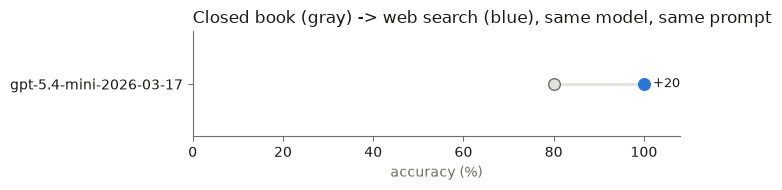

In [ ]:
paired = (
    df[df["method"].isin(["closed_book", "web_search"])].pivot_table(
        index="model", columns="method", values="is_correct", aggfunc="mean"
    )
    * 100
)
paired = paired.dropna().sort_values("closed_book")

fig, ax = plt.subplots(figsize=(7, max(2.0, 0.9 + 0.5 * len(paired))))
for y, (model, row) in enumerate(paired.iterrows()):
    ax.plot(
        [row["closed_book"], row["web_search"]],
        [y, y],
        color=NEUTRAL,
        linewidth=2,
        zorder=1,
    )
    ax.scatter(row["closed_book"], y, s=70, color=NEUTRAL, edgecolor=MUTED, zorder=2)
    ax.scatter(row["web_search"], y, s=70, color=BLUE, zorder=2)
    ax.text(
        row["web_search"] + 2,
        y,
        f"+{row['web_search'] - row['closed_book']:.0f}"
        if row["web_search"] >= row["closed_book"]
        else f"{row['web_search'] - row['closed_book']:.0f}",
        va="center",
        color=INK,
        fontsize=9,
    )
ax.set_yticks(range(len(paired)), paired.index)
ax.set_xlim(0, 108)
ax.set_ylim(-0.5, len(paired) - 0.5)
ax.set_xlabel("accuracy (%)", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

## 4. Searching vs. citing: two different signals

The tidy CSV drops the raw API payloads, but the per-run JSONL files keep
them, and they record two things that are easy to conflate:

- **Searching** — did the model actually invoke its web-search tool?
  OpenAI logs every `web_search_call` (the queries, plus any pages it
  explicitly opened); Gemini signals a search ran via
  `grounding_metadata.web_search_queries`. Retrieved content lands in the
  model's context either way — you can see it in the input-token counts.
- **Citing** — did the response come back with _attribution metadata_
  tying the answer to source URLs? Gemini returns grounding chunks
  (domain + redirect link) whenever it searches. OpenAI normally returns
  `url_citation` annotations, but when the final message is forced
  through a structured-output JSON schema — as in this sweep — the
  annotations array comes back empty.

So a model can search plenty and still cite nothing. Pull both signals
out of the raw payloads:


In [ ]:
import glob
import json
import urllib.parse

activity_rows, cite_rows = [], []
for path in sorted(glob.glob("../../data/answers/answers_web_search_*.jsonl")):
    with open(path) as f:
        for line in f:
            ans = json.loads(line)
            raw = ans["raw"]
            n_searches, pages_opened, cites = 0, 0, []
            if ans["provider"] == "gemini":
                for cand in raw.get("candidates") or []:
                    meta = cand.get("grounding_metadata") or {}
                    n_searches += len(meta.get("web_search_queries") or [])
                    for chunk in meta.get("grounding_chunks") or []:
                        web = chunk.get("web") or {}
                        if web.get("uri"):
                            cites.append(
                                {"domain": web.get("title"), "url": web["uri"]}
                            )
            else:  # openai
                for item in raw.get("output") or []:
                    if item.get("type") == "web_search_call":
                        action = item.get("action") or {}
                        n_searches += action.get("type") == "search"
                        pages_opened += action.get("type") == "open_page"
                    elif item.get("type") == "message":
                        for part in item.get("content") or []:
                            for note in part.get("annotations") or []:
                                if note.get("type") == "url_citation":
                                    host = urllib.parse.urlparse(note["url"]).netloc
                                    cites.append(
                                        {
                                            "domain": host.removeprefix("www."),
                                            "url": note["url"],
                                        }
                                    )
            base = {
                "question_id": ans["question_id"],
                "article_id": ans["article_id"],
                "model": ans["model"],
                "provider": ans["provider"],
            }
            activity_rows.append(
                {
                    **base,
                    "searched": bool(ans["search_used"]),
                    "n_searches": n_searches,
                    "pages_opened": pages_opened,
                    "n_citations": len(cites),
                }
            )
            cite_rows.extend({**base, **c} for c in cites)

activity = pd.DataFrame(activity_rows)
citations = pd.DataFrame(cite_rows)
activity.groupby("model")[
    ["searched", "n_searches", "pages_opened", "n_citations"]
].sum()

The gap is the story — plot, per model, how many answers _ran a search_
against how many came back with _any citation metadata_:


In [ ]:
per_model = (
    activity.assign(cited=activity["n_citations"] > 0)
    .groupby("model")[["searched", "cited"]]
    .mean()
    * 100
)
n_answers = activity.groupby("model").size()

fig, ax = plt.subplots(figsize=(7, 1.2 + 0.9 * len(per_model)))
bar_h = 0.32
for k, (col, color, label) in enumerate(
    [
        ("searched", NEUTRAL, "ran a web search (tool calls)"),
        ("cited", BLUE, "returned citations (attribution)"),
    ]
):
    ys = [y - (k - 0.5) * bar_h for y in range(len(per_model))]
    bars = ax.barh(ys, per_model[col], height=bar_h * 0.92, color=color, label=label)
    for bar, (model, pct) in zip(bars, per_model[col].items()):
        count = int(round(pct / 100 * n_answers[model]))
        ax.text(
            pct + 1.5,
            bar.get_y() + bar.get_height() / 2,
            f"{count}/{n_answers[model]}",
            va="center",
            color=INK,
            fontsize=8.5,
        )
ax.set_yticks(range(len(per_model)), per_model.index)
ax.set_xlim(0, 100)
ax.set_xlabel("% of web-search answers", color=MUTED)
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.set_title(
    "Searching is not citing: tool use vs. attribution, per model",
    loc="left",
    color=INK,
)
clean_axes(ax)
plt.tight_layout()
plt.show()

Opposite failure modes: **GPT searches constantly but attributes
nothing** — the structured-output schema strips its `url_citation`
annotations, so the only URL traces it leaves are explicit `open_page`
actions. **Gemini rarely bothers to search** — but when it does, every
grounded answer arrives with receipts, because search and citation are
one mechanism (grounding) rather than two.

That means the domain analysis below necessarily covers the Gemini runs:


The domain mix is the interesting part: the questions were built _from_
Guardian articles, so theguardian.com is the ground truth — everything
else is the model corroborating (or substituting) from elsewhere:


In [ ]:
domain_counts = citations["domain"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(7, max(2.5, 0.3 * len(domain_counts))))
colors = [BLUE if d == "theguardian.com" else NEUTRAL for d in domain_counts.index]
ax.barh(domain_counts.index, domain_counts.values, color=colors, height=0.7)
for y, v in enumerate(domain_counts.values):
    ax.text(v + 0.05, y, str(v), va="center", color=INK, fontsize=8.5)
ax.set_xlabel("times cited", color=MUTED)
ax.set_title("Domains cited by web search (Guardian in blue)", loc="left", color=INK)
ax.xaxis.get_major_locator().set_params(integer=True)
clean_axes(ax)
plt.tight_layout()
plt.show()

### Did search find the _source_ article?

Every question was generated from one specific Guardian article, and its
`article_id` is exactly that article's URL path on theguardian.com.
Gemini's citation links are redirects, so for the Guardian-domain
citations we resolve them with `toolkit.utils.resolve_redirect_urls` —
parallel HEAD requests to Google's redirect endpoint only (the Guardian
itself is never contacted) — and compare the final path against the
source article:


In [ ]:
from toolkit.utils import resolve_redirect_urls

guardian = citations[citations["domain"] == "theguardian.com"].copy()
resolved = resolve_redirect_urls(guardian["url"])
guardian["resolved_path"] = guardian["url"].map(
    lambda u: urllib.parse.urlparse(resolved[u] or "").path.strip("/")
)
guardian["exact_article"] = guardian["resolved_path"] == guardian["article_id"]

per_answer = citations.groupby(["question_id", "model"]).agg(
    n_citations=("url", "size"),
    guardian_cited=("domain", lambda d: (d == "theguardian.com").any()),
)
per_answer["exact_article"] = (
    guardian.groupby(["question_id", "model"])["exact_article"]
    .any()
    .reindex(per_answer.index, fill_value=False)
)

n = len(per_answer)
print(f"Of the {n} web-search answers with citations:")
print(f"  cited theguardian.com:      {per_answer['guardian_cited'].sum()}/{n}")
print(f"  found the exact article:    {per_answer['exact_article'].sum()}/{n}")
guardian[["article_id", "resolved_path", "exact_article"]]

Search rarely lands back on the article the question came from — most
answers are grounded in _other_ coverage of the same story (wire services,
other outlets, primary sources). That's fine when the story is widely
reported, and exactly where search struggles when the Guardian is the only
outlet carrying the detail.


## 5. Inside the debates

Did the agents actually _debate_, or just agree three times? The
transcripts (JSONL only — the CSV drops them) tell us how often the vote
was unanimous, split, or tied, and how often the discussion **changed the
outcome** — a final answer different from what round 0's majority would
have been:


5 debates | outcome changed by discussion: 1 (20%)


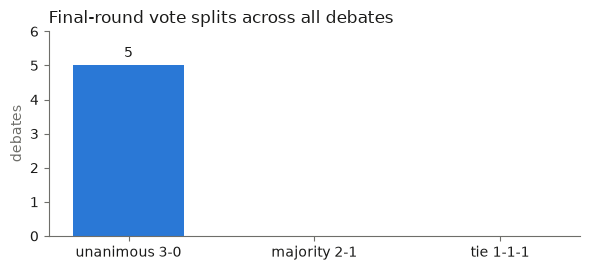

In [ ]:
from pathlib import Path
import json

# Private helper, reused here to recompute each debate's round-0 vote.
from toolkit.debate import _aggregate_votes

rows = []
for fp in sorted(Path("../../data/answers").glob("answers_debate_*.jsonl")):
    for line in fp.read_text().splitlines():
        rec = json.loads(line)
        d = rec["debate"]
        votes = sorted(d["vote_counts"].values(), reverse=True)
        split = "-".join(map(str, votes + [0] * (d["n_agents"] - len(votes))))
        r0_letter, _, _ = _aggregate_votes(d["transcript"][0])
        rows.append(
            {
                "model": rec["model"],
                "split": split,
                "changed": rec["answer_letter"] != r0_letter,
                "is_correct": rec["is_correct"],
            }
        )
deb = pd.DataFrame(rows)
print(
    f"{len(deb)} debates | outcome changed by discussion: "
    f"{deb['changed'].sum()} ({deb['changed'].mean():.0%})"
)

splits = deb["split"].value_counts().reindex(["3-0-0", "2-1-0", "1-1-1"], fill_value=0)
fig, ax = plt.subplots(figsize=(6, 2.8))
colors = [BLUE if s == "3-0-0" else NEUTRAL for s in splits.index]
bars = ax.bar(
    ["unanimous 3-0", "majority 2-1", "tie 1-1-1"],
    splits.values,
    color=colors,
    width=0.6,
)
ax.set_ylim(0, splits.max() * 1.2)
for bar, v in zip(bars, splits.values):
    if v:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            v + splits.max() * 0.03,
            str(v),
            ha="center",
            va="bottom",
            color=INK,
        )
ax.set_title("Final-round vote splits across all debates", loc="left", color=INK)
ax.set_ylabel("debates", color=MUTED)
clean_axes(ax)
plt.tight_layout()
plt.show()

## 6. The map

| This notebook | Where it lives                                                |
| ------------- | ------------------------------------------------------------- |
| §1 tidy CSV   | `scripts/04-3_combine_answers.py`                             |
| §2–4 analysis | figures here, from `answers_combined.csv` + the debate JSONLs |

---

### Next up: Step 5

The models have answered. Last step: a live website where the humans in the room
answer the same 100 questions — and we watch the leaderboard update in real
time. Humans vs. closed book vs. search vs. debate.
